# Figure 3 -- Mutational-profile validation (AUC) and TF-group contribution decomposition

**Region ordering**: `Mutational_profiles`/`Contribution_profiles` (produced by
`train_model_pipeline.py`) are computed from `mutagenesis_region_reference.csv`'s `WT_seq`
column, in that column's row order -- so `id` below is read directly from that file's
`Region` column, in the same order.

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn import metrics

sys.path.insert(0, os.path.join('..', 'plotting'))
sys.path.insert(0, '.')
from plot_utils import return_sig_tfs
from data_preps import Motifs

OUTPUT_DIR = '../output_files'
INPUT_DIR = '../input_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

POOLING = {'lfc': 'avgpooling', 'dht': 'maxpooling'}

def find_output(prefix, output_name, n_mots=647):
    pattern = os.path.join(OUTPUT_DIR, f'{prefix}_{output_name}_bin700bp_{POOLING[output_name]}_S0_*{n_mots}mots.npy')
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern}. Run train_model_pipeline.py first.")
    if len(matches) > 1:
        raise RuntimeError(f"Ambiguous match for '{output_name}': {matches}")
    return matches[0]

with np.load(f'{INPUT_DIR}/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load(f'{INPUT_DIR}/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)

C:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## TF significant-weight sets (needed by both sections below)

In [2]:
coef_bs_lfc = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_lfc_bin700bp_avgpooling_S0_*647mots.npy'))[0])
coef_bs_dht = np.load(glob.glob(os.path.join(OUTPUT_DIR, 'Ridge_coef_bootstrapped_dht_bin700bp_maxpooling_S0_*647mots.npy'))[0])

pos_lfc, neg_lfc = return_sig_tfs(coef_bs_lfc, tfs, CI=95)
pos_dht, neg_dht = return_sig_tfs(coef_bs_dht, tfs, CI=95)

## AUC plot (Figure 3B/C)

In [3]:
folder_path = f'{OUTPUT_DIR}/'
score_x0s0_dht = np.load(find_output('Mutational_profiles', 'dht'))
score_x0s0_lfc = np.load(find_output('Mutational_profiles', 'lfc'))

df_mut_all = pd.read_csv(f'{INPUT_DIR}/Complete_Mut_Data_LibVariant30_Pscount5.csv')

# --- region order for the Mutational_profiles/Contribution_profiles array rows ---
# Same row order as mutagenesis_region_reference.csv's WT_seq column, which is what
# train_model_pipeline.py fed into the mutational/contribution-profile computation.
id = pd.read_csv(f'{INPUT_DIR}/mutagenesis_region_reference.csv')['Region'].values

df_mut_all['LnFCWT_MLE'] = df_mut_all['LFC2WT_MLE'] * np.log(2)
df_mut = df_mut_all[df_mut_all['#_Plasmids'] > 2]
df_mut = df_mut[df_mut['Variants'].str.split(' ').apply(len) < 3]

df_mut['Location'] = df_mut['Variants'].str.split(':').str[1]
df_mut = df_mut.groupby(['Region', 'Location'])['LnFCWT_MLE'].mean().reset_index()
df_mut = df_mut[df_mut['Location'] != 'WT']
df_mut['Location'] = df_mut['Location'].astype(int)


all_ids = []
for i in range(40):
    all_ids.append([id[i]] * 309)
all_ids = np.array(all_ids).flatten()


score_x0s0_dht_ = np.mean(score_x0s0_dht, axis=2)
score_x0s0_lfc_ = np.mean(score_x0s0_lfc, axis=2)


model_names = ['LogFC model', 'LogDHT model']
data = {'Region': all_ids, 'Location': np.arange(2, 311).tolist() * 40,
        model_names[0]: score_x0s0_lfc_.flatten(), model_names[1]: score_x0s0_dht_.flatten()}
model_scores = pd.DataFrame(data)

grouped_df = pd.merge(df_mut, model_scores, on=['Region', 'Location'])

In [4]:
#+ve  mutations
auc_list = []
auc_model = []

thr_neg = -np.round(np.arange(0, 2.1, 0.1), decimals=10)[::-1]
thr_pos = -np.round(np.arange(-0.6, 0.1, 0.1), decimals=10)[::-1]

threshold_list = np.concatenate((thr_neg, thr_pos))

num_1s = np.zeros(len(threshold_list))
absolute_1s = np.zeros(len(threshold_list))

for model in model_names:

  auc = []
  f, c = 0, 0
  for th in threshold_list:

    lf_ex = grouped_df['LnFCWT_MLE'].values

    if th <= 0 and f == 0:
      if th == 0:
        f = 1
      cls_ex = lf_ex < th
      lf_model = grouped_df[model].values

    elif th >= 0:
      if th == 0:
        f = 0
      cls_ex = lf_ex > th
      lf_model = -grouped_df[model].values

    num_1s[c] = np.sum(cls_ex) / len(cls_ex)
    absolute_1s[c] = sum(cls_ex)
    auc.append(metrics.roc_auc_score(cls_ex, lf_model))
    c += 1

  auc_list.append(auc)
  auc_model.append(model)

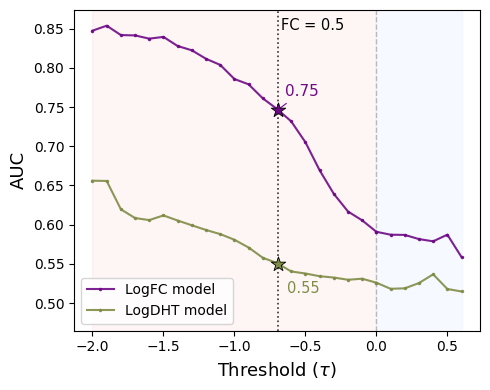

In [5]:
tau_target = np.log(0.5)
auc_half = [np.interp(tau_target, threshold_list, a) for a in auc_list]

plt.figure(figsize=(5, 4))

# Background
x_min, x_max = min(threshold_list), max(threshold_list)
plt.axvspan(x_min, 0, color='#fde8e8', alpha=0.4, zorder=-1)
plt.axvspan(0, x_max, color='#eaf2ff', alpha=0.4, zorder=-1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# ln(0.5) reference
plt.axvline(tau_target, color='black', linestyle=':', linewidth=1.2, alpha=0.8)

colors = ['#6E0A85', '#808C46']

for i in range(len(model_names)):
    plt.plot(threshold_list, auc_list[i],
             marker='.', markersize=3,
             label=model_names[i],
             color=colors[i], alpha=0.9, zorder=3)

    plt.scatter(tau_target, auc_half[i],
                marker='*', s=120,
                color=colors[i],
                edgecolor='black', linewidth=0.6,
                zorder=5)

plt.annotate(f'{auc_half[0]:.2f}',
             xy=(tau_target, auc_half[0]),
             xytext=(5, 10),
             textcoords='offset points',
             fontsize=11,
             color=colors[0],
             arrowprops=dict(arrowstyle='-',
                             color=colors[0],
                             lw=0.8))

# auc_list can contain NaN at extreme thresholds where only one class is present
# (roc_auc_score is undefined there) -- use NaN-safe min/max for the axis limits.
plt.ylim(np.nanmin(auc_list) - 0.05, np.nanmax(auc_list) + 0.02)
plt.ylabel('AUC', fontsize=13)
plt.xlabel(r'Threshold ($\tau$)', fontsize=13)

plt.text(tau_target + 0.06,
         auc_half[1] - 0.037,
         f'{auc_half[1]:.2f}',
         fontsize=10.5,
         color=colors[1])

plt.text(tau_target + 0.02, plt.ylim()[1] - 0.01,
         'FC = 0.5',
         ha='left', va='top',
         fontsize=10.5)

plt.legend(fontsize=10, loc='lower left', frameon=True)

plt.tight_layout()

plt.savefig(f'{FIGURES_DIR}/fig3c_auc_vs_threshold.pdf')
plt.savefig(f'{FIGURES_DIR}/fig3c_auc_vs_threshold.svg')
plt.show()

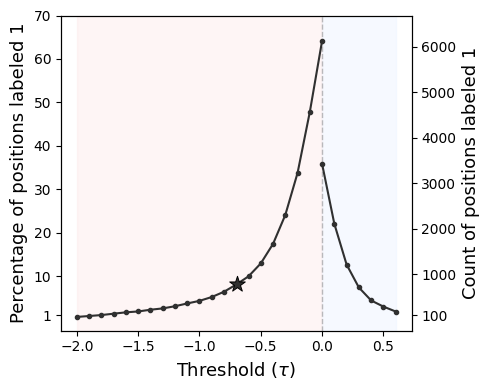

In [6]:
fig, ax1 = plt.subplots(figsize=(5, 4))

x_all = np.concatenate([thr_neg, thr_pos])
x_min, x_max = min(x_all), max(x_all)

ax1.axvspan(x_min, 0, color='#fde8e8', alpha=0.4, zorder=-1)  # red (LoF)
ax1.axvspan(0, x_max, color='#eaf2ff', alpha=0.4, zorder=-1)  # blue (GoF)
ax1.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax1.plot(thr_neg, num_1s[:-len(thr_pos)] * 100, '.-', color='#303030', zorder=3)
ax1.plot(thr_pos, num_1s[-len(thr_pos):] * 100, '.-', color='#303030', zorder=3)

ax1.set_xlabel(r'Threshold ($\tau$)', fontsize=13)
ax1.set_ylabel('Percentage of positions labeled 1', fontsize=13)

# ax2 is a pure unit-rescaled view of ax1 (count = percentage/100 * N), not a second
# plotted curve. Plotting absolute_1s separately here used to draw a second,
# independently-autoscaled copy of the same underlying data in the same color, which
# doesn't land on exactly the same pixels as ax1's curve and looks like doubled dots.
N = len(grouped_df)
ax2 = ax1.twinx()
ax2.set_ylabel('Count of positions labeled 1', fontsize=13)

ax1.set_yticks(np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]) * 100)
ax2.set_yticks([100, 1000, 2000, 3000, 4000, 5000, 6000, 7000])
ax2.set_ylim(np.array(ax1.get_ylim()) * N / 100)

ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

# Original hardcoded 777 (the count at tau=ln(0.5) from a prior run); interpolated here instead.
count_at_tau = np.interp(tau_target, threshold_list, absolute_1s)
ax2.scatter(tau_target, count_at_tau,
            marker='*',
            s=140,
            color='#303030',
            edgecolor='black',
            linewidth=0.7,
            zorder=5)

fig.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3b_position_counts_vs_threshold.pdf')
plt.savefig(f'{FIGURES_DIR}/fig3b_position_counts_vs_threshold.svg')
plt.show()

## Contribution of TFs in mutational profiles (Figure 3A + all-40-enhancers supplementary PDF)

In [7]:
df_mut_all = pd.read_csv(f'{INPUT_DIR}/Complete_Mut_Data_LibVariant30_Pscount5.csv')
df_mut = df_mut_all[df_mut_all['#_Plasmids'] > 2]
df_mut = df_mut[df_mut['Variants'].str.split(' ').apply(len) < 3]

df_mut['Location'] = df_mut['Variants'].str.split(':').str[1]
df_mut = df_mut.groupby(['Region', 'Location'])['LFC2WT_MLE'].mean().reset_index()
df_mut = df_mut[df_mut['Location'] != 'WT']
df_mut['Location'] = df_mut['Location'].astype(int)

sets = {
    "lfc_pos": pos_lfc,
    "lfc_neg": neg_lfc,
    "dht_pos": pos_dht,
    "dht_neg": neg_dht,
}

set_lf_pos = set(sets['lfc_pos'])
set_dht_pos = set(sets['dht_pos'])

ARs_pos = np.array(list(set_lf_pos - set_dht_pos))  # Only in A
consts_pos = np.array(list(set_dht_pos - set_lf_pos))  # Only in B
pioneers = np.array(list(set_lf_pos & set_dht_pos))  # A and B


ARs_ind_pos = np.array([i for i, value in enumerate(tfs) if value in ARs_pos])
consts_ind_pos = np.array([i for i, value in enumerate(tfs) if value in consts_pos])
pioneers_ind = np.array([i for i, value in enumerate(tfs) if value in pioneers])


scores_tfs_dht = np.load(find_output('Contribution_profiles', 'dht'))
scores_tfs_lfc = np.load(find_output('Contribution_profiles', 'lfc'))

scores_lfc = np.mean(scores_tfs_lfc, axis=-1)
scores_dht = np.mean(scores_tfs_dht, axis=-1)

### Figure 3A -- single representative enhancer (`overlapped_read_128`), the one shown in the paper

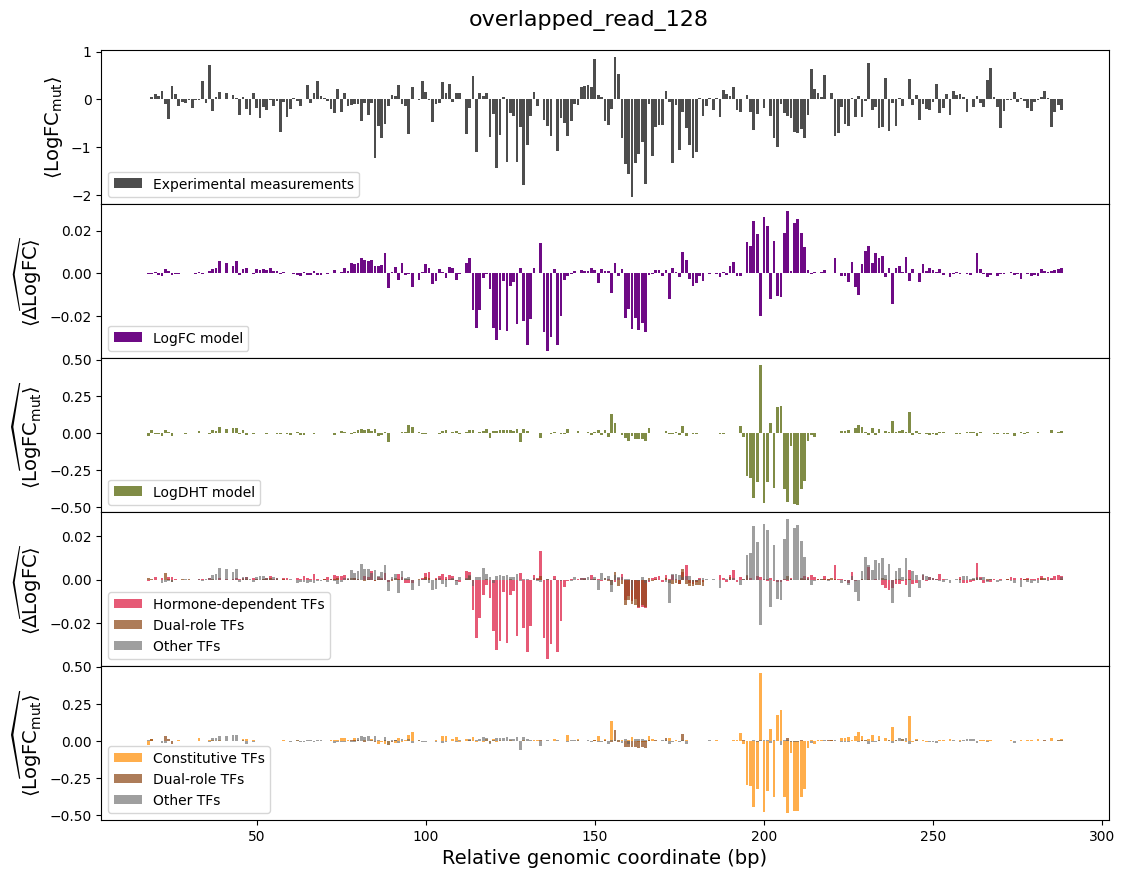

In [8]:
REGION_OF_INTEREST = 'overlapped_read_128'
i = np.where(id == REGION_OF_INTEREST)[0][0]

pos1 = df_mut[df_mut['Region'] == id[i]]['Location'].values[:-1].astype(int)
lfc = df_mut[df_mut['Region'] == id[i]]['LFC2WT_MLE'].values[:-1]

sort_ind = np.argsort(pos1)
pos1 = pos1[sort_ind]
lfc = lfc[sort_ind]

x = np.unique(pos1) - 2

fig, axs = plt.subplots(5, figsize=(13, 10))
fig.suptitle(f'{id[i]}', fontsize=16, y=0.92)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)


axs[0].bar(x, lfc, color=(0.3, 0.3, 0.3), label='Experimental measurements')
axs[1].bar(x, -np.sum(scores_lfc, axis=0)[i, x], color='#6E0A85', label='LogFC model')
axs[2].bar(x, -np.sum(scores_dht, axis=0)[i, x], color='#808C46', label='LogDHT model')


all_not_ar = np.setdiff1d(np.arange(293), np.concatenate((ARs_ind_pos, pioneers_ind)))
axs[3].bar(x, -np.sum(scores_lfc[ARs_ind_pos, i, :], axis=0)[x], alpha=0.7, color='crimson', label='Hormone-dependent TFs')
axs[3].bar(x, -np.sum(scores_lfc[pioneers_ind, i, :], axis=0)[x], alpha=0.7, color='#8B4513', label='Dual-role TFs')
axs[3].bar(x, -np.sum(scores_lfc[all_not_ar, i, :], axis=0)[x], alpha=0.6, color='#606060', label='Other TFs')


all_not_const = np.setdiff1d(np.arange(293), np.concatenate((consts_ind_pos, pioneers_ind)))
axs[4].bar(x, -np.sum(scores_dht[consts_ind_pos, i, :], axis=0)[x], alpha=0.7, color='#FF8C00', label='Constitutive TFs')
axs[4].bar(x, -np.sum(scores_dht[pioneers_ind, i, :], axis=0)[x], alpha=0.7, color='#8B4513', label='Dual-role TFs')
axs[4].bar(x, -np.sum(scores_dht[all_not_const, i, :], axis=0)[x], alpha=0.6, color='#606060', label='Other TFs')

for j, ax in enumerate(axs.flat):
    ax.legend(loc='lower left', fontsize=10)

for j, ax in enumerate(axs.flat[:-1]):
    ax.set_xticks([])

axs[4].set_xlabel("Relative genomic coordinate (bp)", fontsize=14)

axs[0].set_ylabel(r'$\langle \text{LogFC}_{\mathrm{mut}}\rangle$', fontsize=14)
axs[1].set_ylabel(r'$\langle \widehat{\Delta \text{LogFC}}\rangle$', fontsize=14)
axs[2].set_ylabel(r'$\langle \widehat{\text{LogFC}_{\mathrm{mut}}}\rangle$', fontsize=14)
axs[3].set_ylabel(r'$\langle \widehat{\Delta \text{LogFC}}\rangle$', fontsize=14)
axs[4].set_ylabel(r'$\langle \widehat{\text{LogFC}_{\mathrm{mut}}}\rangle$', fontsize=14)

fig.savefig(f'{FIGURES_DIR}/fig3a_{REGION_OF_INTEREST}.pdf', bbox_inches='tight')
fig.savefig(f'{FIGURES_DIR}/fig3a_{REGION_OF_INTEREST}.svg', bbox_inches='tight')
plt.show()

In [9]:
pdf_filename = f'{FIGURES_DIR}/fig3a_contribution_profiles_40_enhancers.pdf'

with PdfPages(pdf_filename) as pdf:
    for i in range(40):
        pos1 = df_mut[df_mut['Region'] == id[i]]['Location'].values[:-1].astype(int)
        lfc = df_mut[df_mut['Region'] == id[i]]['LFC2WT_MLE'].values[:-1]

        sort_ind = np.argsort(pos1)
        pos1 = pos1[sort_ind]
        lfc = lfc[sort_ind]

        x = np.unique(pos1) - 2

        fig, axs = plt.subplots(5, figsize=(13, 10))
        fig.suptitle(f'{id[i]}', fontsize=16, y=0.92)
        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0)


        axs[0].bar(x, lfc, color=(0.3, 0.3, 0.3), label='Experimental measurements')
        axs[1].bar(x, -np.sum(scores_lfc, axis=0)[i, x], color='#6E0A85', label='LogFC model')
        axs[2].bar(x, -np.sum(scores_dht, axis=0)[i, x], color='#808C46', label='LogDHT model')


        all_not_ar = np.setdiff1d(np.arange(293), np.concatenate((ARs_ind_pos, pioneers_ind)))
        axs[3].bar(x, -np.sum(scores_lfc[ARs_ind_pos, i, :], axis=0)[x], alpha=0.7, color='crimson', label='Hormone-dependent TFs')
        axs[3].bar(x, -np.sum(scores_lfc[pioneers_ind, i, :], axis=0)[x], alpha=0.7, color='#8B4513', label='Dual-role TFs')
        axs[3].bar(x, -np.sum(scores_lfc[all_not_ar, i, :], axis=0)[x], alpha=0.6, color='#606060', label='Other TFs')


        all_not_const = np.setdiff1d(np.arange(293), np.concatenate((consts_ind_pos, pioneers_ind)))
        axs[4].bar(x, -np.sum(scores_dht[consts_ind_pos, i, :], axis=0)[x], alpha=0.7, color='#FF8C00', label='Constitutive TFs')
        axs[4].bar(x, -np.sum(scores_dht[pioneers_ind, i, :], axis=0)[x], alpha=0.7, color='#8B4513', label='Dual-role TFs')
        axs[4].bar(x, -np.sum(scores_dht[all_not_const, i, :], axis=0)[x], alpha=0.6, color='#606060', label='Other TFs')

        for j, ax in enumerate(axs.flat):
            ax.legend(loc='lower left', fontsize=10)

        for j, ax in enumerate(axs.flat[:-1]):
            ax.set_xticks([])

        axs[4].set_xlabel("Relative genomic coordinate (bp)", fontsize=14)

        axs[0].set_ylabel(r'$\langle \text{LogFC}_{\mathrm{mut}}\rangle$', fontsize=14)
        axs[1].set_ylabel(r'$\langle \widehat{\Delta \text{LogFC}}\rangle$', fontsize=14)
        axs[2].set_ylabel(r'$\langle \widehat{\text{LogFC}_{\mathrm{mut}}}\rangle$', fontsize=14)
        axs[3].set_ylabel(r'$\langle \widehat{\Delta \text{LogFC}}\rangle$', fontsize=14)
        axs[4].set_ylabel(r'$\langle \widehat{\text{LogFC}_{\mathrm{mut}}}\rangle$', fontsize=14)

        pdf.savefig(fig, bbox_inches='tight', dpi=250)
        plt.close(fig)

print(f"Saved all 40 figures to {pdf_filename}")

Saved all 40 figures to ../figures/fig3a_contribution_profiles_40_enhancers.pdf
